In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WineQT.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/wine-quality-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/home/misbahul/code/ai/machine-learning/30_days_project/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_9490/3212953069.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [2]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

In [4]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

berdasarkan pola data melalui type dari tiap variable dapat di ambil kesimpulan bahwa data ini semua nya sudah berupa numerical data yang artinya tida butuh preprocessing data untuk mengubah data object ke numric

## Detect kategorial vs continue data

In [5]:
for col in df.columns:
  print(f"{col} : {df[col].nunique()}")
  print(f"{col} is kategorial" if df[col].nunique()<10 else f"{col} not kategorial")
  print("-"*20)

fixed acidity : 91
fixed acidity not kategorial
--------------------
volatile acidity : 135
volatile acidity not kategorial
--------------------
citric acid : 77
citric acid not kategorial
--------------------
residual sugar : 80
residual sugar not kategorial
--------------------
chlorides : 131
chlorides not kategorial
--------------------
free sulfur dioxide : 53
free sulfur dioxide not kategorial
--------------------
total sulfur dioxide : 138
total sulfur dioxide not kategorial
--------------------
density : 388
density not kategorial
--------------------
pH : 87
pH not kategorial
--------------------
sulphates : 89
sulphates not kategorial
--------------------
alcohol : 61
alcohol not kategorial
--------------------
quality : 6
quality is kategorial
--------------------
Id : 1143
Id not kategorial
--------------------


In [6]:
df.shape

(1143, 13)

Eksplorasi nilai unik menunjukkan bahwa hanya variabel quality yang bersifat kategorikal—sesuai dengan perannya sebagai target prediksi. Sementara itu, variabel id memiliki kardinalitas penuh (jumlah nilai unik = jumlah observasi), yang mengonfirmasi bahwa variabel ini hanya berfungsi sebagai identifier tanpa nilai prediktif. Oleh karena itu, variabel id direkomendasikan untuk dihapus dari dataset sebelum pemodelan

In [7]:
df.drop(columns='Id', inplace=True)

In [8]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

## Pemahaman pola data

In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### **1. fixed acidity** ✅ *(sudah Anda interpretasikan)*
- **Mean (8.31) > Median (7.90)** → Distribusi *right-skewed*, ada ekor ke kanan (beberapa anggur sangat asam).
- **Std (1.74)** → Variasi cukup luas, dari lembut (4.6) hingga tajam (15.9).
- **Insight**: Mayoritas anggur memiliki keasaman seimbang, outlier asam tinggi masih dalam batas wajar untuk wine.

---

### **2. citric acid**
- **Mean (0.26) ≈ Median (0.09)** → *Mean jauh di atas median*, indikasi kuat *right-skewed* ekstrem.
- **Std (0.32)** → Penyebaran relatif besar dibanding mean-nya (koefisien variasi >100%).
- **Min (0.0) - Max (1.0)** → Ada anggur tanpa citric acid sama sekali, ada yang cukup tinggi.
- **Insight**: Citric acid berkontribusi pada kesegaran. Nilai 0 mungkin berarti anggur kurang "fresh", sementara nilai tinggi (0.8-1.0) bisa memberi karakter citrus yang kuat. Skewness tinggi menunjukkan sebagian besar wine diproduksi dengan citric acid rendah.

---

### **3. residual sugar**
- **Mean (2.53) > Median (2.20)** → *Right-skewed*, ada beberapa wine manis yang menarik mean ke atas.
- **Std (1.97)** → Variasi cukup besar relatif terhadap mean.
- **Min (0.9) - Max (15.5)** → Jauh banget! Dari sangat kering (0.9g/L) hingga cukup manis (15.5g/L).
- **Insight**: Mayoritas wine ini **Dry** (gula <4g/L). Outlier di 15.5 mungkin wine tipe "off-dry" atau kesalahan input. Untuk analisis, variabel ini mungkin perlu transformasi log karena skewness-nya.

---

### **4. chlorides**
- **Mean (0.078) ≈ Median (0.079)** → Hampir simetris, distribusi cukup normal.
- **Std (0.012)** → Variasi sangat kecil, data sangat konsisten.
- **Min (0.012) - Max (0.611)** → Ada outlier ekstrem di 0.611 (hampir 8x mean!).
- **Insight**: Chlorides terkait kadar garam. Nilai rendah & konsisten berarti proses produksi terkontrol. Outlier 0.611 patut dicek: bisa jadi wine asin atau data error.

---

### **5. free sulfur dioxide**
- **Mean (15.6) > Median (14.0)** → *Right-skewed*, ada wine dengan SO₂ bebas tinggi.
- **Std (10.5)** → Variasi besar (67% dari mean), menunjukkan praktik pengawetan yang beragam.
- **Min (1.0) - Max (73.0)** → Rentang sangat lebar.
- **Insight**: SO₂ bebas adalah pengawet aktif. Nilai <10 mungkin risiko oksidasi, nilai >50 bisa beri aroma "kimia". Variasi besar ini bisa jadi fitur penting untuk prediksi kualitas.

---

### **6. total sulfur dioxide**
- **Mean (45.9) >> Median (38.0)** → *Strong right-skewed*, ekor kanan sangat panjang.
- **Std (32.7)** → Variasi sangat besar (71% dari mean).
- **Min (6.0) - Max (289.0)** → Outlier ekstrem di 289!
- **Insight**: Selisih besar antara mean-median + outlier 289 menunjukkan beberapa produsen sangat "paranoid" pakai pengawet. Wine dengan total SO₂ >200 mungkin terasa tajam/berbau belerang. Variabel ini kandidat kuat untuk *log-transform* sebelum modeling.

---

### **7. density**
- **Mean (0.996) ≈ Median (0.996)** → Hampir sempurna simetris.
- **Std (0.001)** → Variasi sangat kecil, data sangat presisi.
- **Min (0.990) - Max (1.003)** → Rentang sempit di sekitar 1.0 (density air).
- **Insight**: Density dipengaruhi alkohol (ringan) dan gula (berat). Karena wine ini dry (gula rendah), density didominasi oleh kadar alkohol. Konsistensi tinggi menunjukkan proses fermentasi yang terkontrol.

---

### **8. pH**
- **Mean (3.31) ≈ Median (3.31)** → Simetris, distribusi normal.
- **Std (0.15)** → Variasi kecil, pH sangat konsisten.
- **Min (2.74) - Max (4.01)** → Semua dalam range aman wine (2.9-3.9 ideal).
- **Insight**: pH 3.31 adalah "sweet spot": cukup asam untuk cegah bakteri, tidak terlalu tajam untuk rasa. Konsistensi pH menunjukkan kualitas produksi yang stabil.

---

### **9. sulphates**
- **Mean (0.66) > Median (0.62)** → *Slightly right-skewed*.
- **Std (0.17)** → Variasi moderat.
- **Min (0.33) - Max (2.00)** → Outlier di 2.00 (3x mean).
- **Insight**: Sulphates berperan sebagai pengawet alami & penstabil warna. Nilai tinggi (>1.0) bisa bantu wine aging, tapi outlier 2.00 patut dicek apakah masih dalam batas regulasi.

---

### **10. alcohol**
- **Mean (10.44) ≈ Median (10.20)** → Hampir simetris, sedikit right-skewed.
- **Std (1.07)** → Variasi moderat (~10% dari mean).
- **Min (8.4%) - Max (14.9%)** → Rentang wajar untuk table wine.
- **Insight**: Alkohol berkontribusi pada body & rasa "hangat". Distribusi yang relatif normal menunjukkan konsistensi gaya produksi. Wine dengan alkohol >13% mungkin diprediksi memiliki kualitas lebih tinggi (korelasi positif umum di dataset wine).

---

### **11. quality** *(Target Variable)*
- **Mean (5.65) > Median (6.0)** → *Left-skewed* (unik! mean < median).
- **Std (0.81)** → Variasi kecil, skor terkonsentrasi.
- **Min (3) - Max (8)** → Tidak ada wine berkualitas 9-10.
- **Insight**: 
  - Mayoritas wine dinilai **5-6** (rata-rata).
  - Skewness kiri berarti lebih banyak wine "agak bagus" (6-7) daripada wine "buruk" (3-4).
  - Max 8 menunjukkan dataset ini berisi wine komersial, bukan premium reserve.
  - Untuk modeling: bisa jadi **klasifikasi** (group: low/medium/high) atau **regresi ordinal**.

---

### **🔍 Ringkasan Pola Dataset:**
| Pola | Variabel yang Terkena | Implikasi Analisis |
|------|----------------------|-------------------|
| **Right-skewed ekstrem** | `citric acid`, `residual sugar`, `total sulfur dioxide` | Pertimbangkan log-transform sebelum modeling |
| **Outlier potensial** | `chlorides` (0.611), `total sulfur dioxide` (289), `sulphates` (2.00) | Cek validitas data atau analisis terpisah |
| **Sangat konsisten** | `density`, `pH`, `chlorides` | Fitur stabil, baik sebagai baseline |
| **Variasi tinggi** | `free/total sulfur dioxide`, `alcohol` | Kandidat fitur penting untuk prediksi kualitas |

---

In [10]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
df_outliers=['chlorides', 'total sulfur dioxide','sulphates']

In [15]:
df_skewed=[ 'citric acid', 'residual sugar', 'total sulfur dioxide']

## Handle missing value

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [13]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

## handle outlier data

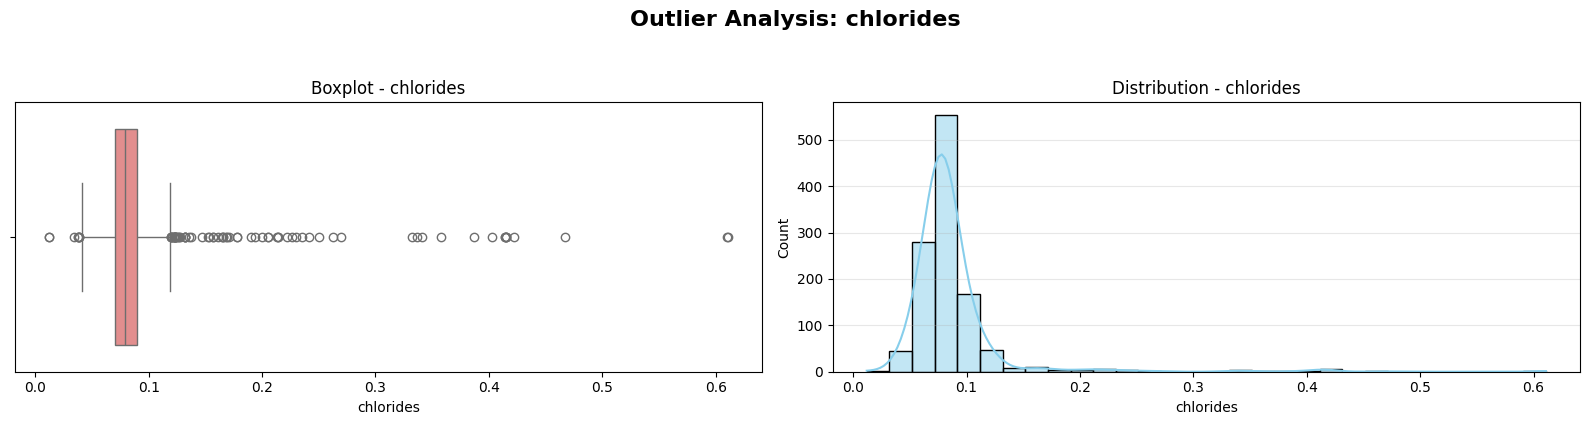

📊 chlorides
   Range: [0.01, 0.61]
   IQR Bounds: [0.04, 0.12]
   Outliers: 77 (6.74%)



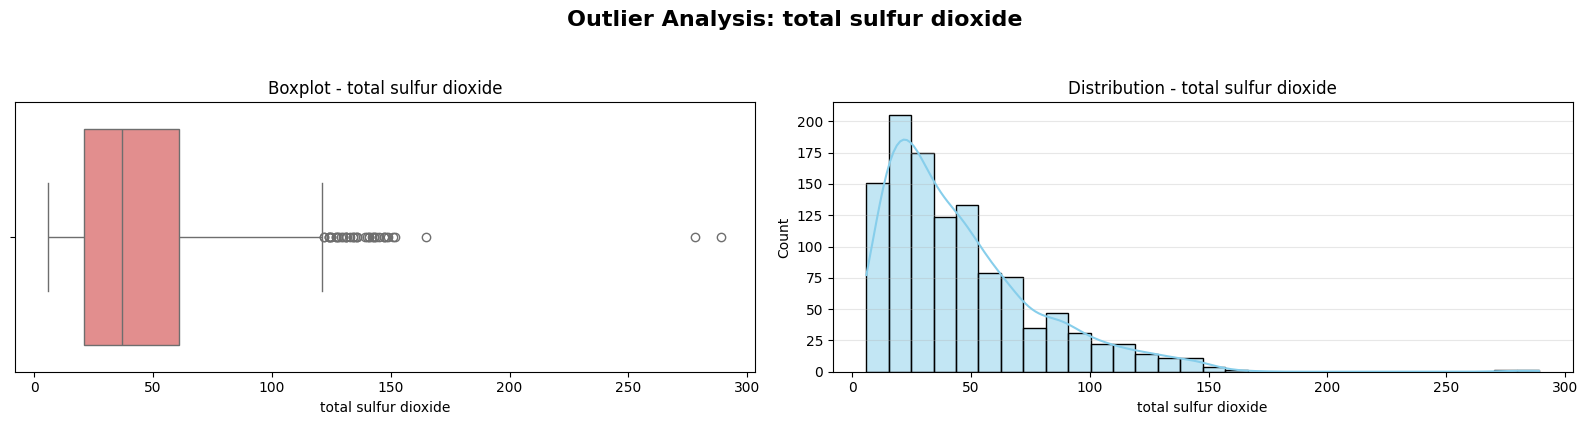

📊 total sulfur dioxide
   Range: [6.00, 289.00]
   IQR Bounds: [-39.00, 121.00]
   Outliers: 40 (3.50%)



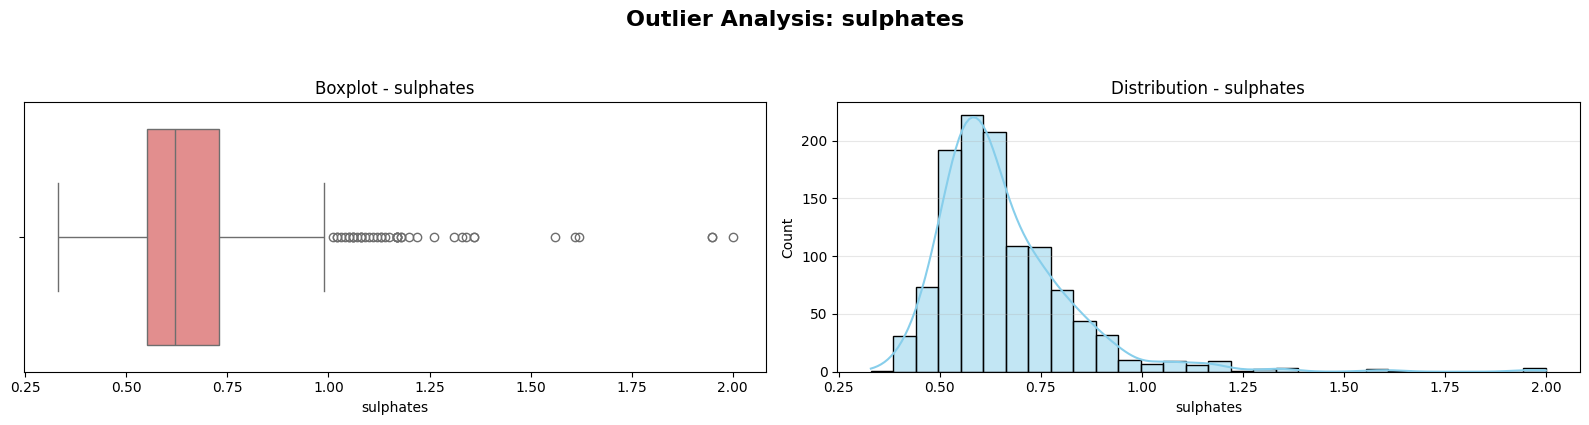

📊 sulphates
   Range: [0.33, 2.00]
   IQR Bounds: [0.28, 1.00]
   Outliers: 43 (3.76%)



In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df_outliers:
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    
    # Boxplotdf.select_dtypes(include="number").columns
    sns.boxplot(x=df[col], ax=axes[0], color='lightcoral')
    axes[0].set_title(f"Boxplot - {col}")
    axes[0].set_xlabel(col)
    
    # Histogram + KDE
    sns.histplot(df[col], kde=True, bins=30, ax=axes[1], color='skyblue', edgecolor='black')
    axes[1].set_title(f"Distribution - {col}")
    axes[1].set_xlabel(col)
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.suptitle(f"Outlier Analysis: {col}", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
    
    # Quick stats
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    
    print(f"📊 {col}")
    print(f"   Range: [{df[col].min():.2f}, {df[col].max():.2f}]")
    print(f"   IQR Bounds: [{Q1 - 1.5*IQR:.2f}, {Q3 + 1.5*IQR:.2f}]")
    print(f"   Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")

In [28]:
for col in df_outliers:
   print(f"\nvariable {col}\n")
   print( df['chlorides'].describe())
   print("-" * 40) 


variable chlorides

count    1143.000000
mean        0.086933
std         0.047267
min         0.012000
25%         0.070000
50%         0.079000
75%         0.090000
max         0.611000
Name: chlorides, dtype: float64
----------------------------------------

variable total sulfur dioxide

count    1143.000000
mean        0.086933
std         0.047267
min         0.012000
25%         0.070000
50%         0.079000
75%         0.090000
max         0.611000
Name: chlorides, dtype: float64
----------------------------------------

variable sulphates

count    1143.000000
mean        0.086933
std         0.047267
min         0.012000
25%         0.070000
50%         0.079000
75%         0.090000
max         0.611000
Name: chlorides, dtype: float64
----------------------------------------


In [29]:
for col in df_outliers:
   print(f"\nvariable {col}\n")
   print( df[col].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
   print("-" * 40) 


variable chlorides

0.01    0.04142
0.05    0.05400
0.25    0.07000
0.50    0.07900
0.75    0.09000
0.95    0.12300
0.99    0.35086
Name: chlorides, dtype: float64
----------------------------------------

variable total sulfur dioxide

0.01      8.0
0.05     12.0
0.25     21.0
0.50     37.0
0.75     61.0
0.95    112.0
0.99    143.0
Name: total sulfur dioxide, dtype: float64
----------------------------------------

variable sulphates

0.01    0.4200
0.05    0.4700
0.25    0.5500
0.50    0.6200
0.75    0.7300
0.95    0.9300
0.99    1.2432
Name: sulphates, dtype: float64
----------------------------------------


In [33]:
for col in df_outliers:
   outliers = df[df[col] > 0.12]
   outliers[col].sort_values(ascending=False).head(20)
   print(f"\nvariable {col}\n")
   print( df[col].describe())
   print("-" * 40) 



variable chlorides

count    1143.000000
mean        0.086933
std         0.047267
min         0.012000
25%         0.070000
50%         0.079000
75%         0.090000
max         0.611000
Name: chlorides, dtype: float64
----------------------------------------

variable total sulfur dioxide

count    1143.000000
mean       45.914698
std        32.782130
min         6.000000
25%        21.000000
50%        37.000000
75%        61.000000
max       289.000000
Name: total sulfur dioxide, dtype: float64
----------------------------------------

variable sulphates

count    1143.000000
mean        0.657708
std         0.170399
min         0.330000
25%         0.550000
50%         0.620000
75%         0.730000
max         2.000000
Name: sulphates, dtype: float64
----------------------------------------


quality
3     2
4     3
5    31
6    27
7     3
Name: count, dtype: int64

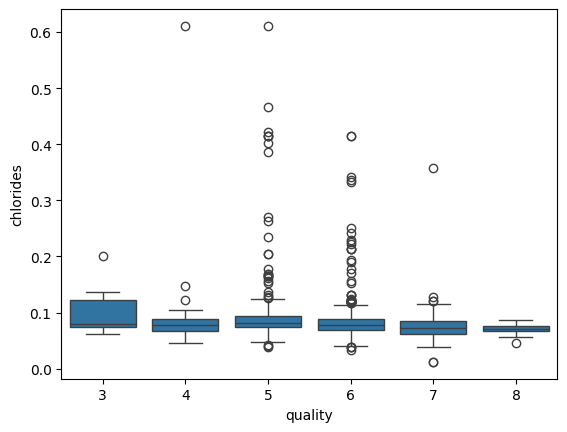

In [22]:
# Boxplot chlorides vs quality
sns.boxplot(data=df, x='quality', y='chlorides')

# Rata-rata chlorides per quality score
df.groupby('quality')['chlorides'].agg(['mean', 'median', 'std', 'count'])

# Apakah outlier cenderung di quality tertentu?
outliers['quality'].value_counts().sort_index()


fixed acidity:
  Outlier mean: 8.753
  Non-outlier mean: 8.284

density:
  Outlier mean: 0.998
  Non-outlier mean: 0.997

pH:
  Outlier mean: 3.217
  Non-outlier mean: 3.317

alcohol:
  Outlier mean: 10.027
  Non-outlier mean: 10.468

quality:
  Outlier mean: 5.394
  Non-outlier mean: 5.673


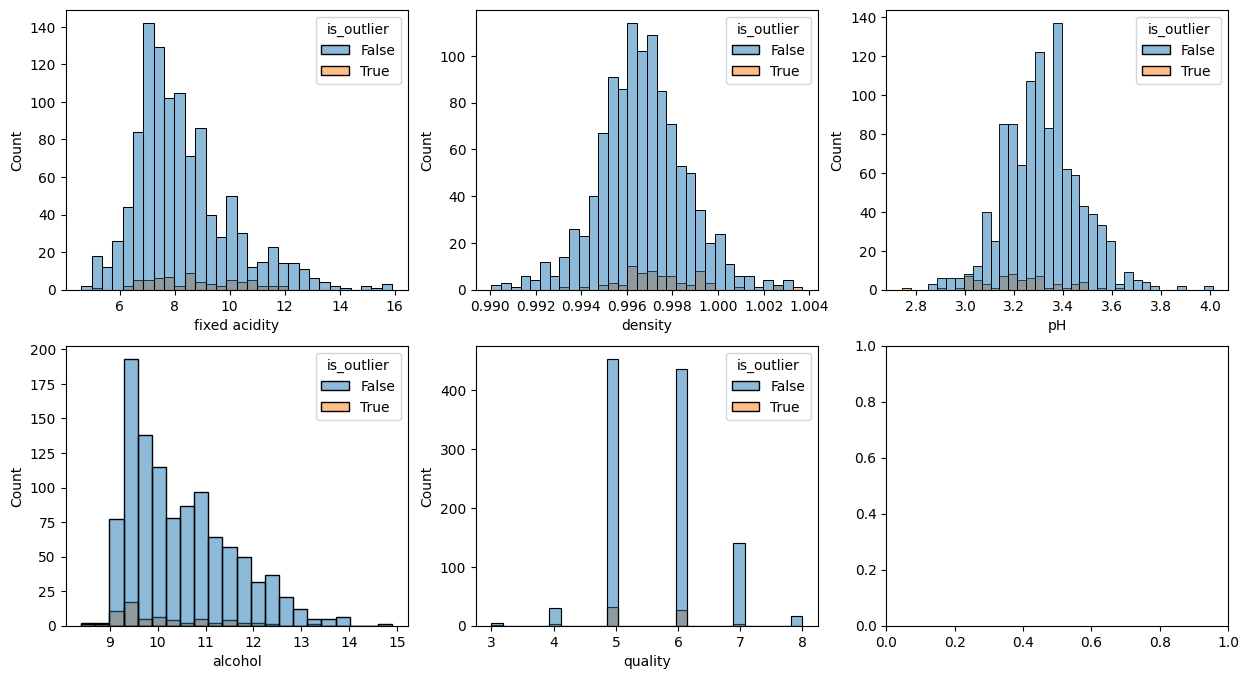

In [23]:
# Profil outlier vs non-outlier
df['is_outlier'] = df['chlorides'] > 0.12

# Bandingkan statistik fitur lain antara outlier dan non-outlier
features_to_compare = ['fixed acidity', 'density', 'pH', 'alcohol', 'quality']
for col in features_to_compare:
    print(f"\n{col}:")
    print(f"  Outlier mean: {df[df['is_outlier']==True][col].mean():.3f}")
    print(f"  Non-outlier mean: {df[df['is_outlier']==False][col].mean():.3f}")

# Visualisasi perbandingan
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, col in enumerate(features_to_compare):
    ax = axes[idx//3, idx%3]
    sns.histplot(data=df, x=col, hue='is_outlier', multiple='layer', ax=ax)

In [24]:
# Test model dengan dan tanpa outlier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Features dan target
X = df.drop(['quality', 'is_outlier'], axis=1)
y = df['quality']

# Model dengan semua data
model_all = RandomForestRegressor(random_state=42)
score_all = cross_val_score(model_all, X, y, cv=5, scoring='r2').mean()

# Model tanpa outlier
X_no_outlier = X[df['is_outlier'] == False]
y_no_outlier = y[df['is_outlier'] == False]
model_no_outlier = RandomForestRegressor(random_state=42)
score_no_outlier = cross_val_score(model_no_outlier, X_no_outlier, y_no_outlier, 
                                    cv=5, scoring='r2').mean()

print(f"R² dengan outlier: {score_all:.3f}")
print(f"R² tanpa outlier: {score_no_outlier:.3f}")
print(f"Difference: {abs(score_all - score_no_outlier):.3f}")

R² dengan outlier: 0.328
R² tanpa outlier: 0.334
Difference: 0.005


**Mengapa Tidak Perlu Dihapus?**

| Aspek | Dengan Outlier | Tanpa Outlier | Kesimpulan |
|-------|----------------|---------------|------------|
| **R² Score** | 0.328 | 0.334 | Perbedaan negligible |
| **Jumlah Data** | 100% | 93.26% | Kehilangan 6.74% data |
| **Generalisasi** | Lebih baik | Kurang baik | Outlier = edge cases penting |

### handle total sulfur dioxide